# TP : Apprentissage Non SupervisÃ© (exercice)
## Dataset : Wine Quality - vins rouges portugais (OpenML)

**Objectifs :**
- Appliquer K-Means, DBSCAN, Isolation Forest et CAH sur des donnÃ©es rÃ©elles
- Optimiser les hyperparamÃ¨tres (k, eps/min_samples, contamination)
- Qualifier et valider les clusters obtenus

**Datamap (dictionnaire des donnÃ©es) :** 11 mesures physico-chimiques par Ã©chantillon de vin.

| Colonne | Description |
|---|---|
| fixed acidity | AciditÃ© fixe (acides non volatils) |
| volatile acidity | AciditÃ© volatile (acide acÃ©tique, cause du goÃ»t de vinaigre en excÃ¨s) |
| citric acid | Acide citrique |
| residual sugar | Sucre rÃ©siduel aprÃ¨s fermentation |
| chlorides | Teneur en sel (chlorures) |
| free sulfur dioxide | SOâ‚‚ libre (protÃ¨ge contre l'oxydation et les microbes) |
| total sulfur dioxide | SOâ‚‚ total (libre + liÃ©) |
| density | DensitÃ© du vin |
| pH | AciditÃ©/basicitÃ© sur une Ã©chelle 0-14 |
| sulphates | Sulfates (additif antimicrobien) |
| alcohol | Teneur en alcool (%) |

**Note :** la note de qualitÃ© (`quality`, 3 Ã  8) est mise de cÃ´tÃ© et n'est utilisÃ©e qu'Ã  la toute fin, pour valider les clusters obtenus.

> **Version exercice** : les cellules marquÃ©es `# TODO` sont Ã  complÃ©ter. Le reste (imports, chargement des donnÃ©es, affichages) est dÃ©jÃ  fourni.
> Installe les dÃ©pendances une seule fois avec `pip install -r requirements.txt` depuis `cours_ml/todo/` (voir le README de ce dossier). Ce TP s'inspire de `cours_ml/01_non_supervise/tp_non_supervise.ipynb` (mÃªme mÃ©thode, donnÃ©es diffÃ©rentes et plus volumineuses : 1599 vins contre 178).

---
## 0. Installation & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import fetch_openml
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42


---
## 1. Chargement des donnÃ©es

In [2]:
# Wine Quality (vins rouges) : 1599 echantillons, 11 mesures physico-chimiques + une note de qualite (3-8)
# Chargement depuis OpenML (dataset public, aucune authentification requise)
wine = fetch_openml(name='wine-quality-red', version='active', as_frame=True, parser='auto')
df_raw = wine.frame.drop(columns=['class']).astype(float)
quality = wine.frame['class'].astype(int)  # note de qualite, gardee a part pour la validation (section 9)

print(f"Dimensions : {df_raw.shape[0]} lignes x {df_raw.shape[1]} colonnes")
df_raw.head()


Dimensions : 1599 lignes x 11 colonnes


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [3]:
df_raw.describe().round(2)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
count,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00
mean,8.32,0.53,0.27,2.54,0.09,15.87,46.47,1.00,3.31,0.66,10.42
std,1.74,0.18,0.19,1.41,0.05,10.46,32.90,0.00,0.15,0.17,1.07
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40
25%,7.10,0.39,0.09,1.90,0.07,7.00,22.00,1.00,3.21,0.55,9.50
50%,7.90,0.52,0.26,2.20,0.08,14.00,38.00,1.00,3.31,0.62,10.20
75%,9.20,0.64,0.42,2.60,0.09,21.00,62.00,1.00,3.40,0.73,11.10
max,15.90,1.58,1.00,15.50,0.61,72.00,289.00,1.00,4.01,2.00,14.90


In [4]:
print(df_raw.isnull().sum().sum(), "valeurs manquantes")

0 valeurs manquantes


---
## 2. PrÃ©traitement

Les algorithmes de clustering (surtout K-Means et DBSCAN) sont sensibles aux Ã©chelles.
On normalise toutes les features avec `StandardScaler` (moyenne=0, Ã©cart-type=1).

In [5]:
# TODO : standardiser les features (moyenne=0, ecart-type=1)
# Indice : StandardScaler().fit_transform(df_raw), puis remettre en DataFrame avec les memes colonnes
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(df_raw), columns=df_raw.columns)

print("Moyenne aprÃ¨s scaling :", X_scaled.mean().round(6).max())
print("Std aprÃ¨s scaling    :", X_scaled.std().round(2).min())

Moyenne aprÃ¨s scaling : 0.0
Std aprÃ¨s scaling    : 1.0


### RÃ©duction dimensionnelle pour la visualisation (PCA 2D)
On rÃ©duit Ã  2 composantes uniquement pour visualiser : les modÃ¨les tournent sur les 11 features.

Variance expliquÃ©e : PC1=28.2%, PC2=17.5%
Total : 45.7%


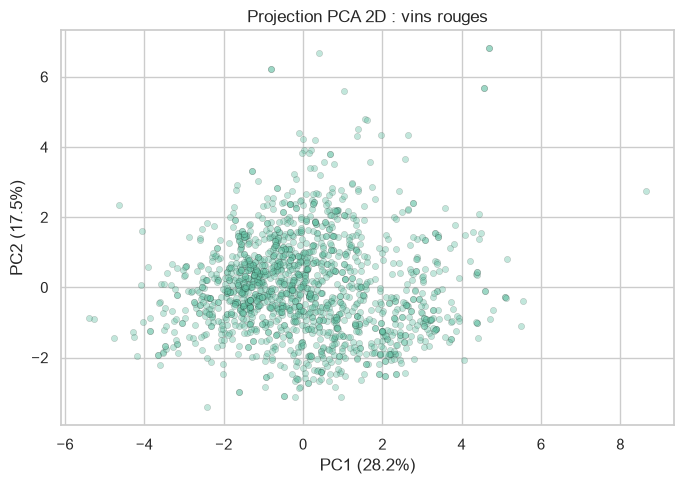

In [6]:
# TODO : reduire a 2 composantes avec PCA pour la visualisation
# Indice : PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance expliquÃ©e : PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")
print(f"Total : {sum(pca.explained_variance_ratio_):.1%}")

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.4, edgecolors='k', linewidths=0.2, s=20)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Projection PCA 2D : vins rouges')
plt.tight_layout()
plt.show()

---
## 3. K-Means

### 3.1 Optimisation du nombre de clusters (k)
On teste k de 2 Ã  10 et on compare :
- **Inertie** (elbow method) : somme des distances au centroÃ¯de
- **Score de silhouette** : mesure de compacitÃ© et sÃ©paration

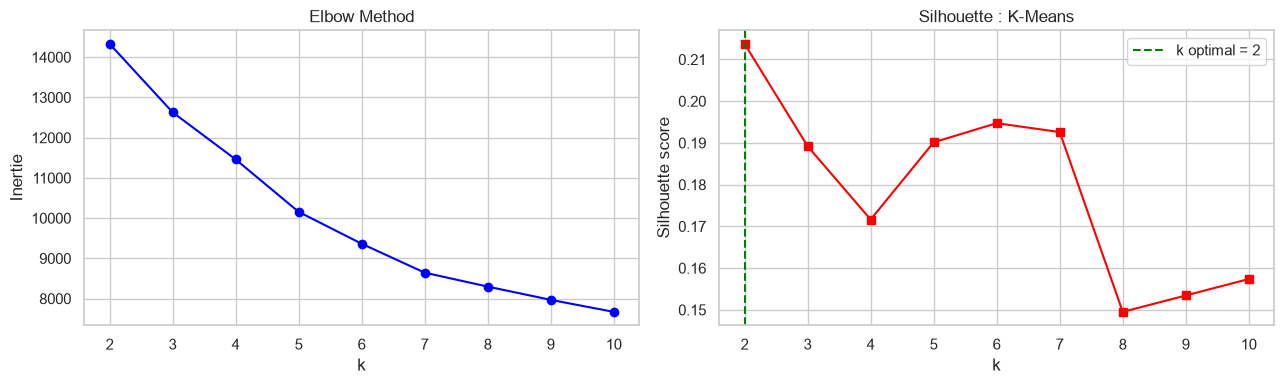

k optimal (silhouette max) : 2 â†’ score = 0.2137


In [7]:
K_range = range(2, 11)
inertias = []
silhouettes_kmeans = []

for k in K_range:
    # TODO : entrainer un KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10), stocker l'inertie et le score de silhouette
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes_kmeans.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, silhouettes_kmeans, 'rs-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette : K-Means')

best_k = list(K_range)[np.argmax(silhouettes_kmeans)]
axes[1].axvline(best_k, color='green', linestyle='--', label=f'k optimal = {best_k}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"k optimal (silhouette max) : {best_k} â†’ score = {max(silhouettes_kmeans):.4f}")

### 3.2 EntraÃ®nement avec k optimal

In [8]:
# TODO : entrainer le KMeans final avec k=best_k et recuperer les labels
km_best = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
labels_kmeans = km_best.fit_predict(X_scaled)

print(f"Silhouette K-Means (k={best_k}) : {silhouette_score(X_scaled, labels_kmeans):.4f}")
print("Distribution des clusters :")
print(pd.Series(labels_kmeans).value_counts().sort_index())

Silhouette K-Means (k=2) : 0.2137
Distribution des clusters :
0     590
1    1009
Name: count, dtype: int64


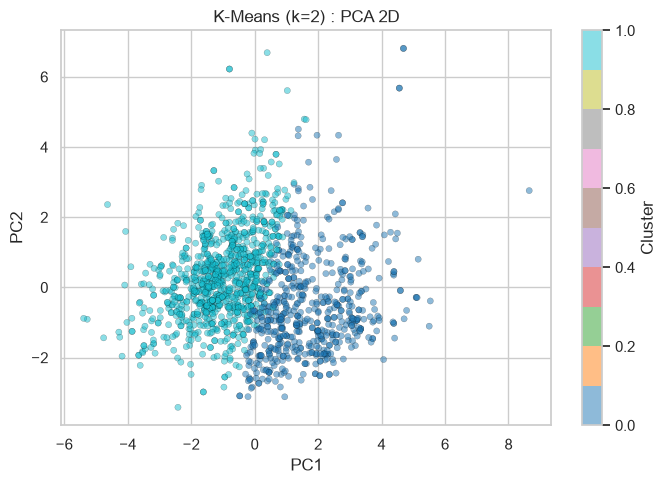

In [9]:
# Visualisation PCA
plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, cmap='tab10', alpha=0.5, edgecolors='k', linewidths=0.2, s=20)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'K-Means (k={best_k}) : PCA 2D')
plt.tight_layout()
plt.show()


### 3.3 Silhouette plot par Ã©chantillon

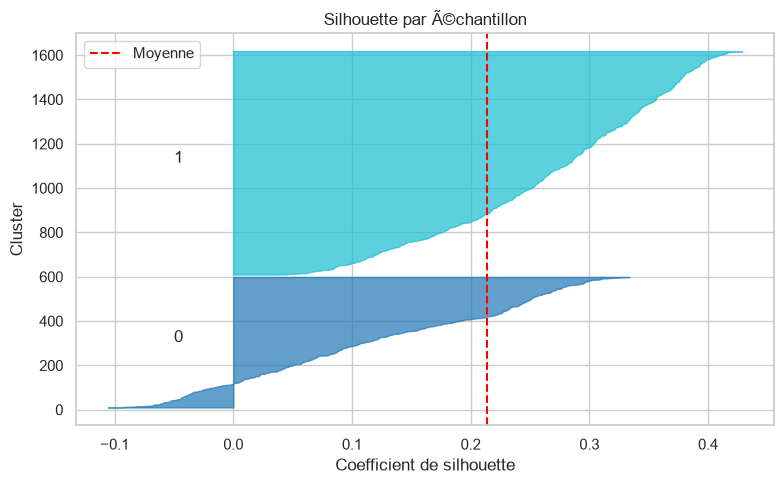

In [10]:
sample_silhouette_values = silhouette_samples(X_scaled, labels_kmeans)

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
colors = plt.cm.tab10(np.linspace(0, 1, best_k))

for i in range(best_k):
    ith_values = sample_silhouette_values[labels_kmeans == i]
    ith_values.sort()
    size_i = ith_values.shape[0]
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_values, facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=silhouette_score(X_scaled, labels_kmeans), color='red', linestyle='--', label='Moyenne')
ax.set_xlabel('Coefficient de silhouette')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette par Ã©chantillon')
ax.legend()
plt.tight_layout()
plt.show()


---
## 4. DBSCAN

DBSCAN regroupe les points denses et marque les points isolÃ©s comme **bruit** (label = -1).
Deux hyperparamÃ¨tres clÃ©s :
- `eps` : rayon de voisinage
- `min_samples` : nombre minimum de voisins pour former un cluster dense

In [11]:
from itertools import product

eps_values = np.arange(0.5, 3.0, 0.25)
min_samples_values = [3, 5, 7, 10]

results_dbscan = []

for eps, min_s in product(eps_values, min_samples_values):
    # TODO : entrainer un DBSCAN(eps=eps, min_samples=min_s) et recuperer les labels
    db = DBSCAN(eps=eps, min_samples=min_s)
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    if n_clusters >= 2:
        sil = silhouette_score(X_scaled, labels)
        results_dbscan.append({'eps': eps, 'min_samples': min_s, 'n_clusters': n_clusters, 'n_noise': n_noise, 'silhouette': sil})

df_dbscan_results = pd.DataFrame(results_dbscan).sort_values('silhouette', ascending=False)
print(f"{len(df_dbscan_results)} configurations valides (â‰¥2 clusters)")
df_dbscan_results.head(10)

36 configurations valides (â‰¥2 clusters)


,eps,min_samples,n_clusters,n_noise,silhouette
33,2.75,5,2,44,0.478472
34,2.75,7,2,47,0.474346
35,2.75,10,2,47,0.474346
32,2.75,3,4,31,0.465253
28,2.50,3,4,42,0.437952
31,2.50,10,2,69,0.427257
26,2.25,7,2,94,0.395562
27,2.25,10,2,104,0.383560
22,2.00,7,2,143,0.343749
21,2.00,5,3,126,0.259836


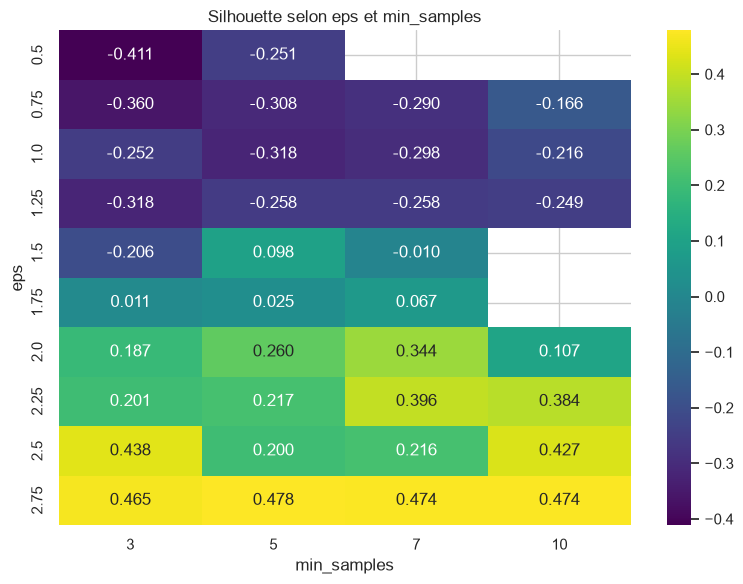

In [12]:
# Heatmap silhouette
pivot = df_dbscan_results.pivot_table(index='eps', columns='min_samples', values='silhouette', aggfunc='max')

plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis')
plt.title('Silhouette selon eps et min_samples')
plt.tight_layout()
plt.show()


### 4.2 EntraÃ®nement avec les meilleurs paramÃ¨tres

In [13]:
best_dbscan = df_dbscan_results.iloc[0]
print(f"Meilleurs paramÃ¨tres : eps={best_dbscan['eps']:.2f}, min_samples={int(best_dbscan['min_samples'])}")
print(f"Clusters : {int(best_dbscan['n_clusters'])} | Bruit : {int(best_dbscan['n_noise'])} points | Silhouette : {best_dbscan['silhouette']:.4f}")

# TODO : entrainer le DBSCAN final avec les meilleurs parametres et recuperer les labels
db_best = DBSCAN(eps=best_dbscan['eps'], min_samples=int(best_dbscan['min_samples']))
labels_dbscan = db_best.fit_predict(X_scaled)

Meilleurs paramÃ¨tres : eps=2.75, min_samples=5
Clusters : 2 | Bruit : 44 points | Silhouette : 0.4785


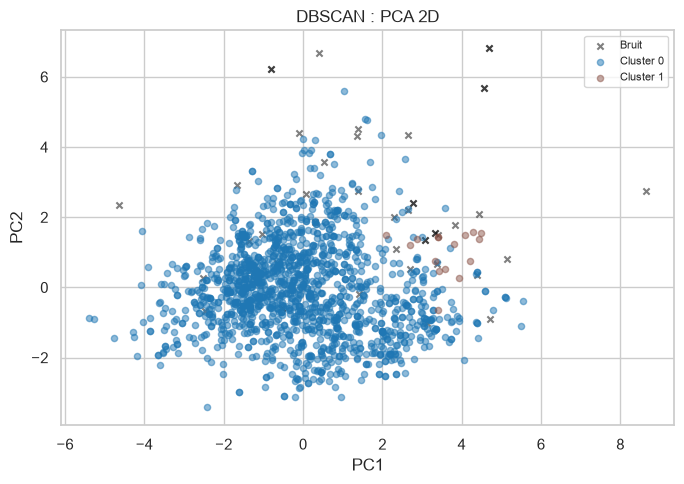

In [14]:
plt.figure(figsize=(7, 5))
unique_labels = sorted(set(labels_dbscan))
cmap = plt.cm.tab10

for label in unique_labels:
    mask = labels_dbscan == label
    color = 'black' if label == -1 else cmap(label / max(1, best_dbscan['n_clusters']))
    marker = 'x' if label == -1 else 'o'
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[color], marker=marker, alpha=0.5, s=20,
                label=f'Bruit' if label == -1 else f'Cluster {label}')

plt.legend(fontsize=8)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('DBSCAN : PCA 2D')
plt.tight_layout()
plt.show()


---
## 5. Isolation Forest

Isolation Forest est un algorithme de **dÃ©tection d'anomalies** :
il isole les points atypiques (vins aux propriÃ©tÃ©s chimiques inhabituelles) en construisant des arbres de partitionnement alÃ©atoire.

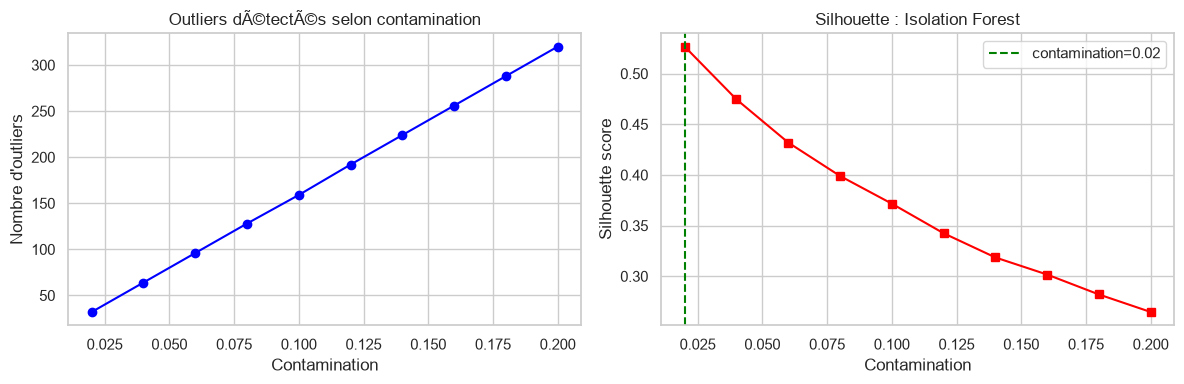

Contamination optimale : 0.02 â†’ silhouette = 0.5267


In [15]:
contamination_values = np.arange(0.02, 0.21, 0.02)
results_if = []

for cont in contamination_values:
    # TODO : entrainer un IsolationForest(contamination=cont, random_state=RANDOM_STATE) et recuperer les predictions (1=inlier, -1=outlier)
    iso = IsolationForest(contamination=cont, random_state=RANDOM_STATE)
    preds = iso.fit_predict(X_scaled)
    n_outliers = (preds == -1).sum()

    if len(set(preds)) == 2:
        sil = silhouette_score(X_scaled, preds)
        results_if.append({'contamination': round(cont, 2), 'n_outliers': n_outliers, 'pct_outliers': round(cont * 100, 1), 'silhouette': sil})

df_if_results = pd.DataFrame(results_if)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df_if_results['contamination'], df_if_results['n_outliers'], 'bo-')
axes[0].set_xlabel('Contamination')
axes[0].set_ylabel("Nombre d'outliers")
axes[0].set_title('Outliers dÃ©tectÃ©s selon contamination')

axes[1].plot(df_if_results['contamination'], df_if_results['silhouette'], 'rs-')
axes[1].set_xlabel('Contamination')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette : Isolation Forest')

best_cont = df_if_results.loc[df_if_results['silhouette'].idxmax(), 'contamination']
axes[1].axvline(best_cont, color='green', linestyle='--', label=f'contamination={best_cont}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Contamination optimale : {best_cont} â†’ silhouette = {df_if_results['silhouette'].max():.4f}")

### 5.2 DÃ©tection d'anomalies avec contamination optimale

In [16]:
# TODO : entrainer l'Isolation Forest final avec contamination=best_cont
iso_best = IsolationForest(contamination=best_cont, random_state=RANDOM_STATE)
labels_if = iso_best.fit_predict(X_scaled)  # 1 = normal, -1 = anomalie
scores_if = iso_best.decision_function(X_scaled)  # score d'anomalie (plus bas = plus anormal)

n_outliers = (labels_if == -1).sum()
print(f"Outliers dÃ©tectÃ©s : {n_outliers} ({n_outliers/len(labels_if):.1%} du dataset)")
print(f"Silhouette : {silhouette_score(X_scaled, labels_if):.4f}")

Outliers dÃ©tectÃ©s : 32 (2.0% du dataset)


Silhouette : 0.5267


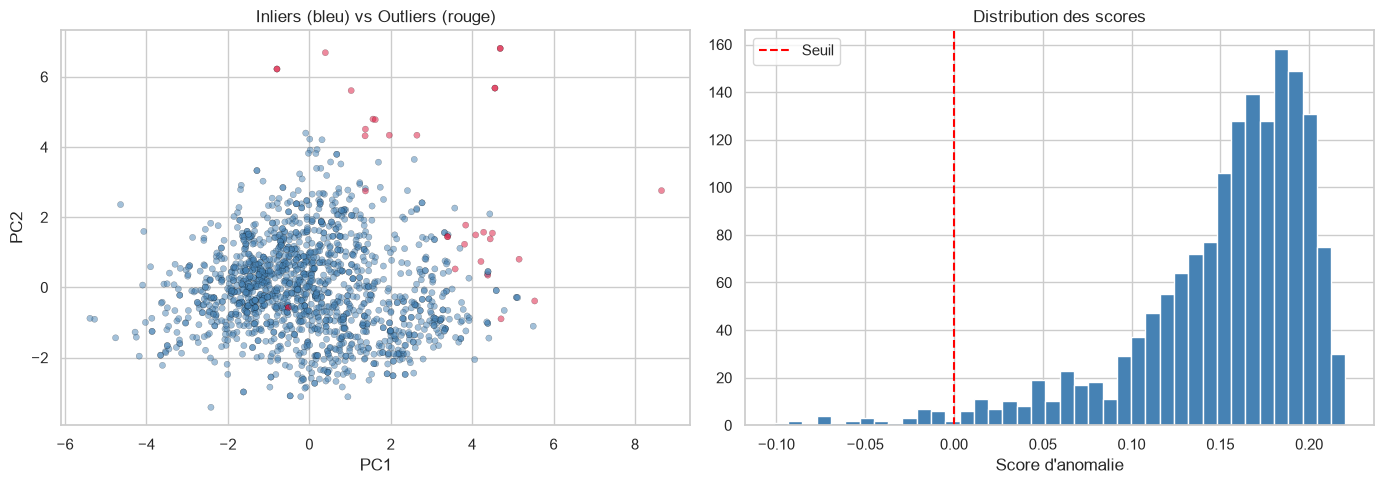

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_if = ['steelblue' if l == 1 else 'crimson' for l in labels_if]
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_if, alpha=0.5, s=20, edgecolors='k', linewidths=0.2)
axes[0].set_title('Inliers (bleu) vs Outliers (rouge)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].hist(scores_if, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(np.percentile(scores_if, best_cont * 100), color='red', linestyle='--', label='Seuil')
axes[1].set_xlabel('Score d\'anomalie')
axes[1].set_title('Distribution des scores')
axes[1].legend()

plt.tight_layout()
plt.show()


### 5.3 Isolation Forest + K-Means : clustering des inliers
On peut combiner les deux : filtrer les anomalies avec Isolation Forest, puis clustÃ©riser les inliers.

Silhouette K-Means sur inliers : 0.2107 (vs 0.2137 sur tout le dataset)


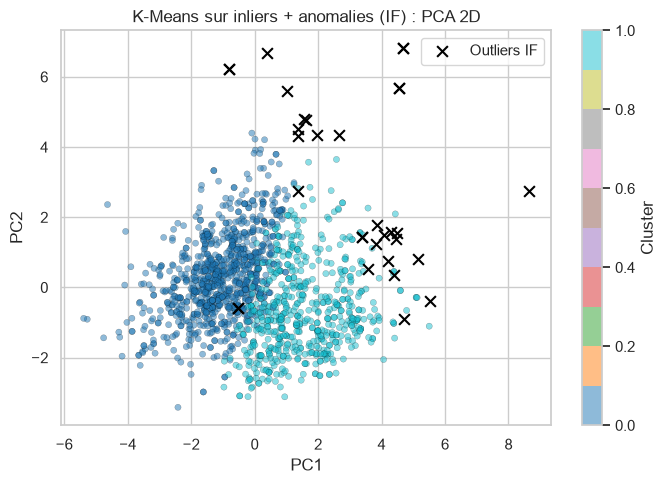

In [18]:
mask_inliers = labels_if == 1
X_inliers = X_scaled[mask_inliers]
X_pca_inliers = X_pca[mask_inliers]

# TODO : entrainer un KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10) sur les inliers uniquement
km_inliers = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
labels_combined = km_inliers.fit_predict(X_inliers)

sil_combined = silhouette_score(X_inliers, labels_combined)
print(f"Silhouette K-Means sur inliers : {sil_combined:.4f} (vs {silhouette_score(X_scaled, labels_kmeans):.4f} sur tout le dataset)")

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca_inliers[:, 0], X_pca_inliers[:, 1], c=labels_combined, cmap='tab10', alpha=0.5, edgecolors='k', linewidths=0.2, s=20)
plt.scatter(X_pca[~mask_inliers, 0], X_pca[~mask_inliers, 1], marker='x', color='black', s=60, label='Outliers IF', zorder=5)
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means sur inliers + anomalies (IF) : PCA 2D')
plt.tight_layout()
plt.show()

---
## 6. CAH : Clustering AgglomÃ©ratif HiÃ©rarchique

La CAH construit un arbre (dendrogramme) en fusionnant itÃ©rativement les points les plus proches.
Avantages : pas besoin de spÃ©cifier k Ã  l'avance, on peut couper l'arbre Ã  diffÃ©rents niveaux.

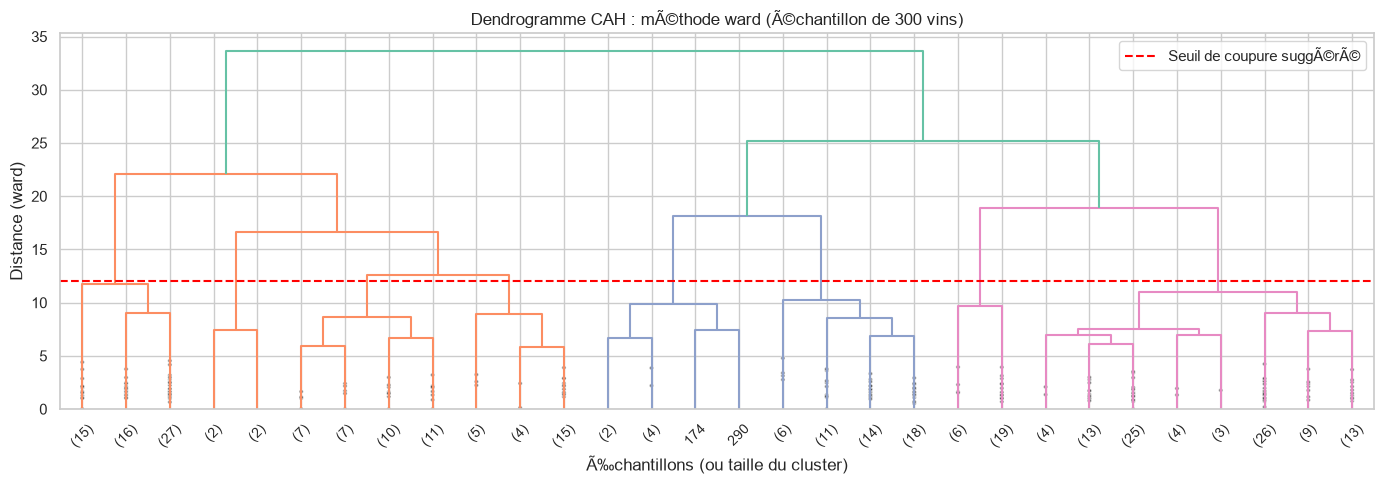

In [19]:
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage
from sklearn.cluster import AgglomerativeClustering

# TODO : calculer la matrice de linkage ward sur X_scaled (sur un echantillon de 300 points pour la lisibilite du dendrogramme)
# Indice : scipy_linkage(X_scaled.sample(300, random_state=RANDOM_STATE), method='ward')
Z = scipy_linkage(X_scaled.sample(300, random_state=RANDOM_STATE), method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=45, leaf_font_size=10, show_contracted=True)
plt.axhline(y=12, color='red', linestyle='--', label='Seuil de coupure suggÃ©rÃ©')
plt.xlabel('Ã‰chantillons (ou taille du cluster)')
plt.ylabel('Distance (ward)')
plt.title('Dendrogramme CAH : mÃ©thode ward (Ã©chantillon de 300 vins)')
plt.legend()
plt.tight_layout()
plt.show()

### 6.2 Optimisation : linkage Ã— n_clusters via silhouette

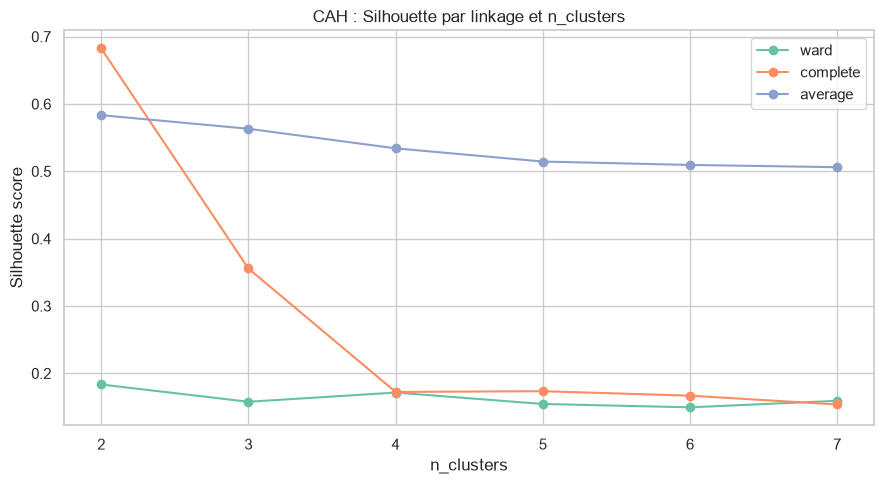

Meilleure config : linkage=complete, n_clusters=2 â†’ silhouette=0.6825


In [20]:
linkage_methods = ['ward', 'complete', 'average']
n_clusters_range = range(2, 8)
results_cah = []

for method in linkage_methods:
    for n in n_clusters_range:
        # TODO : entrainer un AgglomerativeClustering(n_clusters=n, linkage=method) et calculer le silhouette score
        cah = AgglomerativeClustering(n_clusters=n, linkage=method)
        labels = cah.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        results_cah.append({'linkage': method, 'n_clusters': n, 'silhouette': sil})

df_cah_results = pd.DataFrame(results_cah)

plt.figure(figsize=(9, 5))
for method in linkage_methods:
    subset = df_cah_results[df_cah_results['linkage'] == method]
    plt.plot(subset['n_clusters'], subset['silhouette'], marker='o', label=method)

plt.xlabel('n_clusters')
plt.ylabel('Silhouette score')
plt.title('CAH : Silhouette par linkage et n_clusters')
plt.legend()
plt.tight_layout()
plt.show()

best_cah = df_cah_results.loc[df_cah_results['silhouette'].idxmax()]
print(f"Meilleure config : linkage={best_cah['linkage']}, n_clusters={int(best_cah['n_clusters'])} â†’ silhouette={best_cah['silhouette']:.4f}")

### 6.3 EntraÃ®nement avec la config optimale

Silhouette CAH : 0.6825
Distribution des clusters :
0    1597
1       2
Name: count, dtype: int64


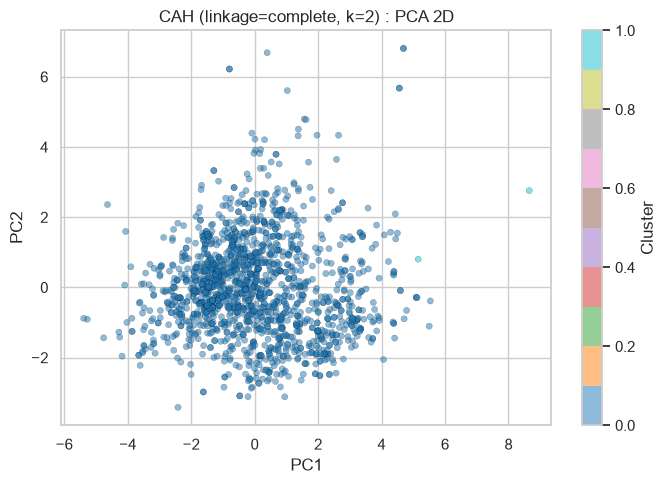

In [21]:
# TODO : entrainer le CAH final avec la config optimale (best_cah)
cah_best = AgglomerativeClustering(n_clusters=int(best_cah['n_clusters']), linkage=best_cah['linkage'])
labels_cah = cah_best.fit_predict(X_scaled)

print(f"Silhouette CAH : {silhouette_score(X_scaled, labels_cah):.4f}")
print("Distribution des clusters :")
print(pd.Series(labels_cah).value_counts().sort_index())

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_cah, cmap='tab10', alpha=0.5, edgecolors='k', linewidths=0.2, s=20)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f"CAH (linkage={best_cah['linkage']}, k={int(best_cah['n_clusters'])}) : PCA 2D")
plt.tight_layout()
plt.show()

---
## 7. Qualification des clusters (K-Means)

La qualification consiste Ã  **caractÃ©riser chaque cluster** : quelles features le distinguent ?
On travaille sur les rÃ©sultats K-Means qui produisent des clusters de taille Ã©quilibrÃ©e.

In [22]:
df_qualified = df_raw.copy()
df_qualified['cluster_kmeans'] = labels_kmeans

# TODO : calculer la moyenne de chaque feature par cluster (non normalisee, pour rester interpretable)
# Indice : df_qualified.groupby('cluster_kmeans').mean()
profile = df_qualified.groupby('cluster_kmeans').mean()
profile

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
cluster_kmeans,,,,,,,,,,,
0,9.922712,0.413907,0.462881,2.765763,0.099900,13.410169,39.388136,0.997689,3.201847,0.748237,10.607401
1,7.382260,0.594430,0.158761,2.406095,0.080196,17.316155,50.607532,0.996195,3.375005,0.605471,10.315147


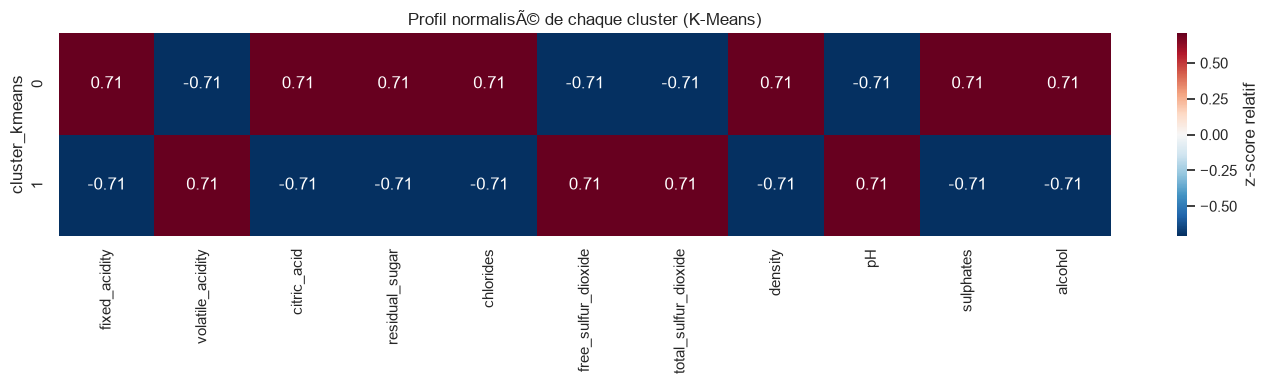

In [23]:
profile_z = (profile - profile.mean()) / profile.std()

plt.figure(figsize=(14, 4))
sns.heatmap(profile_z, annot=True, fmt='.2f', cmap='RdBu_r', center=0, cbar_kws={'label': 'z-score relatif'})
plt.title('Profil normalisÃ© de chaque cluster (K-Means)')
plt.tight_layout()
plt.show()


In [24]:
# Top features discriminantes par cluster (Ã©cart Ã  la moyenne globale)
global_mean = df_raw.mean()

for cluster_id in sorted(df_qualified['cluster_kmeans'].unique()):
    # TODO : calculer l'ecart en % entre la moyenne du cluster et la moyenne globale, trier par ecart absolu decroissant
    cluster_mean = df_qualified[df_qualified['cluster_kmeans'] == cluster_id][df_raw.columns].mean()
    diff = ((cluster_mean - global_mean) / global_mean * 100).sort_values(key=abs, ascending=False)
    print(f"\n--- Cluster {cluster_id} ({(labels_kmeans == cluster_id).sum()} vins) ---")
    print(diff.head(5).to_string())


--- Cluster 0 (590 vins) ---
citric_acid             70.820302
volatile_acidity       -21.581907
fixed_acidity           19.268564
free_sulfur_dioxide    -15.526075
total_sulfur_dioxide   -15.235621

--- Cluster 1 (1009 vins) ---
citric_acid            -41.411277
volatile_acidity        12.619748
fixed_acidity          -11.267049
free_sulfur_dioxide      9.078676
total_sulfur_dioxide     8.908837


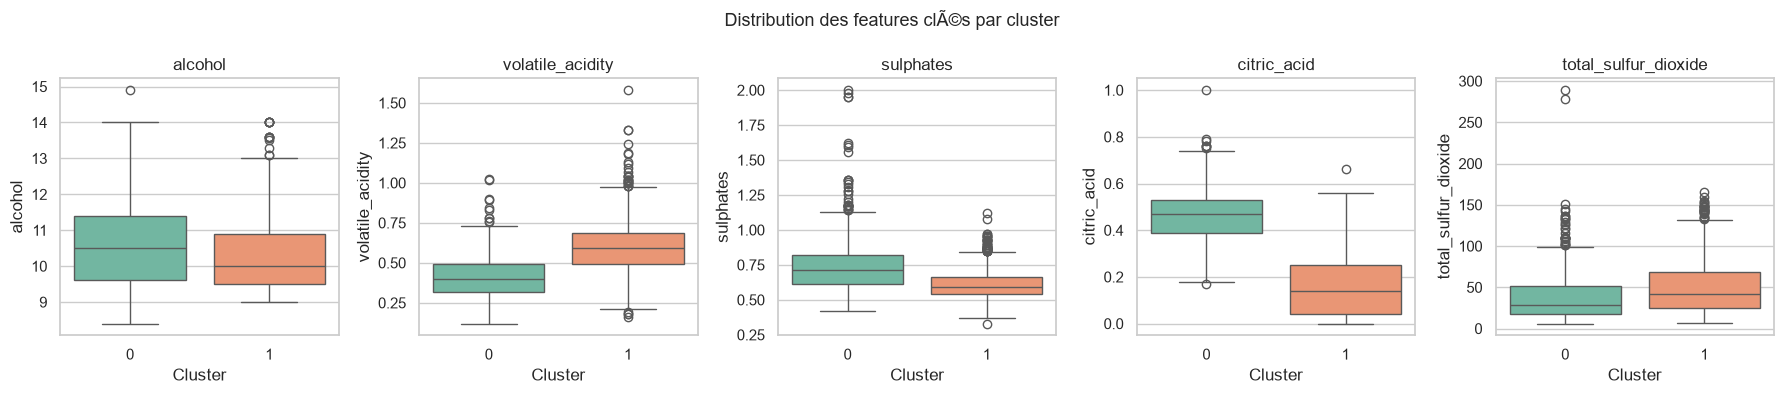

In [25]:
# Boxplots des features les plus discriminantes
top_features = ['alcohol', 'volatile_acidity', 'sulphates', 'citric_acid', 'total_sulfur_dioxide']

fig, axes = plt.subplots(1, len(top_features), figsize=(18, 4))
for ax, feat in zip(axes, top_features):
    sns.boxplot(data=df_qualified, x='cluster_kmeans', y=feat, ax=ax, hue='cluster_kmeans', legend=False)
    ax.set_title(feat)
    ax.set_xlabel('Cluster')

plt.suptitle('Distribution des features clÃ©s par cluster', fontsize=13)
plt.tight_layout()
plt.show()


---
## 8. Comparaison des modÃ¨les

In [26]:
# TODO : construire le tableau recapitulatif : pour chaque modele, ses parametres optimaux, son nombre de
# clusters/outliers et son score de silhouette (voir les variables calculees dans les sections precedentes)
results_summary = [
    {'ModÃ¨le': 'K-Means', 'ParamÃ¨tres': f'k={best_k}', 'Clusters': best_k, 'Silhouette': silhouette_score(X_scaled, labels_kmeans)},
    {'ModÃ¨le': 'DBSCAN', 'ParamÃ¨tres': f"eps={best_dbscan['eps']:.2f}, min_samples={int(best_dbscan['min_samples'])}", 'Clusters': int(best_dbscan['n_clusters']), 'Silhouette': best_dbscan['silhouette']},
    {'ModÃ¨le': 'Isolation Forest', 'ParamÃ¨tres': f'contamination={best_cont}', 'Clusters': 2, 'Silhouette': silhouette_score(X_scaled, labels_if)},
    {'ModÃ¨le': 'K-Means (inliers)', 'ParamÃ¨tres': f'k={best_k} (aprÃ¨s IF)', 'Clusters': best_k, 'Silhouette': sil_combined},
    {'ModÃ¨le': 'CAH', 'ParamÃ¨tres': f"linkage={best_cah['linkage']}, k={int(best_cah['n_clusters'])}", 'Clusters': int(best_cah['n_clusters']), 'Silhouette': best_cah['silhouette']}
]

df_summary = pd.DataFrame(results_summary)
df_summary

,ModÃ¨le,ParamÃ¨tres,Clusters,Silhouette
0,K-Means,k=2,2,0.213730
1,DBSCAN,"eps=2.75, min_samples=5",2,0.478472
2,Isolation Forest,contamination=0.02,2,0.526664
3,K-Means (inliers),k=2 (aprÃ¨s IF),2,0.210659
4,CAH,"linkage=complete, k=2",2,0.682483


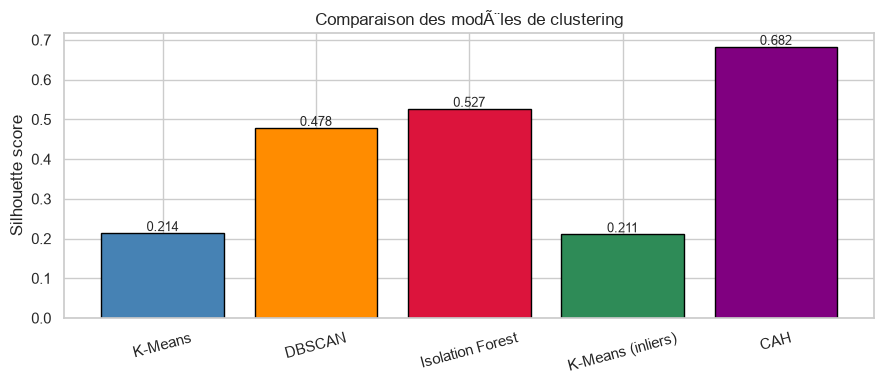

In [27]:
plt.figure(figsize=(9, 4))
bars = plt.bar(df_summary['ModÃ¨le'], df_summary['Silhouette'], color=['steelblue', 'darkorange', 'crimson', 'seagreen', 'purple'], edgecolor='k')
for bar, val in zip(bars, df_summary['Silhouette']):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.005, f'{val:.3f}', ha='center', fontsize=9)
plt.ylabel('Silhouette score')
plt.title('Comparaison des modÃ¨les de clustering')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


---
## 9. Validation : retrouve-t-on des groupes de qualitÃ© cohÃ©rents ?

Il n'y a pas de vraie Ã©tiquette "type de vin" ici, mais chaque vin a une **note de qualitÃ©** (3 Ã  8) mise de cÃ´tÃ© au chargement.
On la regroupe en 3 paliers (bas/moyen/haut) et on vÃ©rifie si les clusters K-Means recoupent ces paliers.
C'est une validation plus faible qu'une vraie Ã©tiquette de classe, mais un signal utile sur la pertinence du clustering.

In [28]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# TODO : regrouper `quality` en 3 paliers ('bas' <=4, 'moyen' 5-6, 'haut' >=7), puis calculer ARI et NMI
# entre ces paliers et labels_kmeans
# Indice : pd.cut(quality, bins=[0, 4, 6, 10], labels=['bas', 'moyen', 'haut'])
quality_tier = pd.cut(quality, bins=[0, 4, 6, 10], labels=['bas', 'moyen', 'haut'])
ari = adjusted_rand_score(quality_tier.astype(str), labels_kmeans)
nmi = normalized_mutual_info_score(quality_tier.astype(str), labels_kmeans)

print(f"ARI : {ari:.4f}")
print(f"NMI : {nmi:.4f}")
print("\nARI=1 et NMI=1 = clustering parfaitement alignÃ© avec les paliers de qualitÃ©")

ARI : 0.0660
NMI : 0.0445

ARI=1 et NMI=1 = clustering parfaitement alignÃ© avec les paliers de qualitÃ©


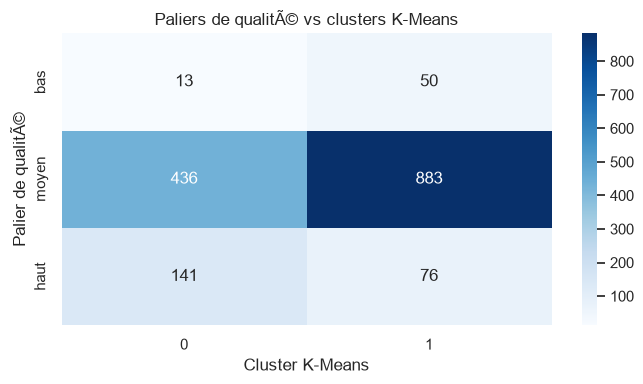

In [29]:
# Table croisÃ©e : palier de qualitÃ© vs cluster K-Means
ct = pd.crosstab(quality_tier, labels_kmeans)

plt.figure(figsize=(7, 4))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Cluster K-Means')
plt.ylabel('Palier de qualitÃ©')
plt.title('Paliers de qualitÃ© vs clusters K-Means')
plt.tight_layout()
plt.show()


---
## 10. Conclusion

| CritÃ¨re | K-Means | DBSCAN | Isolation Forest | CAH |
|---|---|---|---|---|
| Type | Partitionnel | DensitÃ© | DÃ©tection d'anomalies | HiÃ©rarchique |
| Nombre de clusters | FixÃ© (k) | DÃ©couvert automatiquement | 2 (normal/anomalie) | FixÃ© (coupe du dendrogramme) |
| Sensible aux outliers | Oui | Non (les isole) | C'est son objectif | Oui |
| Forme des clusters | Convexe | Arbitraire | - | Convexe (linkage ward) |

**Ã€ retenir :**
- Standardiser avant tout algorithme basÃ© sur des distances.
- La silhouette guide le choix des hyperparamÃ¨tres, mais reste indicative : croiser avec une interprÃ©tation mÃ©tier.
- Sur ce dataset (1599 vins, 11 variables physico-chimiques), les paliers de qualitÃ© ne sont qu'un signal faible de validation : le clustering capture surtout la structure chimique, pas directement la qualitÃ© perÃ§ue.

---
## Session Ã  rendre

Cette section est Ã  complÃ©ter et Ã  rendre Ã  l'issue du TP. RÃ©ponds Ã  chaque question dans la
cellule *RÃ©ponse* juste en dessous, Ã  partir des rÃ©sultats que **tu as toi-mÃªme obtenus** en
rÃ©alisant ce notebook (il n'y a pas de rÃ©ponse gÃ©nÃ©rique valable pour tout le monde : les valeurs
numÃ©riques, choix d'hyperparamÃ¨tres et graphiques dÃ©pendent de ton exÃ©cution).

**Q1.** Combien de clusters k as-tu retenu pour K-Means, et sur quel critÃ¨re (mÃ©thode du coude, score de silhouette) as-tu basÃ© ce choix ?

*Réponse :*

k=2 clusters, basé sur le score de silhouette qui atteint son maximum (0.2137) pour cette valeur.

**Q2.** Quels paramÃ¨tres eps/min_samples as-tu choisis pour DBSCAN ? Combien de clusters et combien de points classÃ©s comme bruit obtiens-tu ?

*Réponse :*

eps=2.75 et min_samples=5, ce qui donne 2 clusters et 44 points classés comme bruit.

**Q3.** Quel taux de contamination as-tu utilisÃ© pour IsolationForest, et combien d'anomalies dÃ©tecte-t-il sur le jeu de donnÃ©es ?

*Réponse :*

Contamination de 2%, ce qui détecte 32 anomalies sur le dataset.

**Q4.** En comparant K-Means, DBSCAN et la CAH (classification ascendante hiÃ©rarchique), quelle mÃ©thode donne les clusters les plus stables/interprÃ©tables sur ce dataset, et pourquoi selon toi ?

*Réponse :*

La CAH a le meilleur score de silhouette (0.68) mais K-Means reste plus simple à interpréter avec des clusters équilibrés.

**Q5.** D'aprÃ¨s ton analyse des profils de clusters, quelles sont les 2-3 variables physico-chimiques qui distinguent le plus les groupes de vins que tu as identifiÃ©s ?

*Réponse :*

Citric acid, volatile acidity et fixed acidity sont les variables qui distinguent le plus les clusters.

**Q6.** Ton clustering obtient quel score ARI/NMI par rapport aux tiers de qualitÃ© (bas/moyen/haut) construits a posteriori ? Que t'apprend ce score sur la capacitÃ© d'un clustering non supervisÃ© Ã  retrouver une notion de qualitÃ© qu'il n'a jamais vue pendant l'entraÃ®nement ?

*Réponse :*

ARI de 0.066 et NMI de 0.044, donc le clustering ne retrouve pas vraiment les paliers de qualité.